In [1]:
# =============================================================================
# Zelle 01 – Setup & Daten laden (Hyperparameter-Tuning Modell B)
# =============================================================================
import sys
sys.path.append('../src')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE
from preprocessing import load_dataset_b, FEATURE_SETS_B, WandstaerkeDNResidualizer, baue_preprocessing_pipeline_b, X_B_MERKMALE_ENCODED, Y_B_MERKMALE

SEED = 42
apply_store44_style()

df_b = load_dataset_b("../data/processed/model_b_preprocessed.csv")

# --- Identische Reproduktion Train/Test-Split und aeussere Folds (Notebook 11) ---
from sklearn.model_selection import train_test_split, KFold

train_idx, test_idx = train_test_split(df_b.index, test_size=0.2, random_state=SEED)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(kf.split(train_idx))
fold_splits_idx = [(train_idx[tr_pos], train_idx[val_pos]) for tr_pos, val_pos in fold_splits]

print(f"Datensatz: {df_b.shape}")
print(f"Train: {len(train_idx)}, Test: {len(test_idx)}, Folds: {len(fold_splits_idx)}")
df_b.head()

Datensatz: (2000, 14)
Train: 1600, Test: 400, Folds: 5


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,schneckendrehzahl,massetemperatur,duesenspalt,vakuumniveau,innenluftdruck,kuehlwassertemperatur,schmelzfestigkeit_proxy,wandtyp_einwandig
0,0.760943,104.164565,1.385443,0.055494,9.400096,0.441754,33.691143,200.906186,1.434323,90.219856,78.197271,19.783884,0.539057,True
1,0.492003,158.608859,2.350657,0.295226,10.168837,0.353945,43.847410,199.855728,2.346622,104.351909,62.177159,19.459041,0.807997,False
2,0.850090,123.340827,1.836205,0.114787,10.907655,0.784632,45.499866,210.933172,1.929061,88.222130,105.947346,16.953516,0.449910,True
3,0.888113,225.335978,2.589429,0.198277,6.963402,0.734473,46.943818,208.291018,2.655661,104.679660,57.771840,21.110659,0.411887,True
4,0.309793,72.773106,1.553914,0.125063,12.279022,0.882630,36.970557,190.000000,1.597350,89.855192,91.287064,19.647650,0.990207,True


## Neue Hyperparameter-Suchräume für Notebook 12

Nach dem Hyperparameter-Herkunfts-Audit (Notebook 11, Abschluss) wurde
festgestellt, dass die meisten Modelle entweder unkritische sklearn-
Defaults nutzten oder Konfigurationen von Modell A (n=560 Training)
übernahmen, ohne für Modell B (n=1600 Training) geprüft zu sein.

**Begründung je Modell:**
- **Ridge:** `alpha` nie geprüft (nur sklearn-Default 1.0) → Suchraum
  [0.01, 0.1, 1.0, 10.0, 100.0] deckt schwache bis starke Regularisierung ab
- **kNN:** `n_neighbors=5` willkürlich übernommen; bei n=1600 (fast 3×
  mehr als Modell A) könnten mehr Nachbarn stabilere Vorhersagen liefern
  → Suchraum [3, 5, 10, 15, 25]
- **RandomForest:** bereits einmal punktuell korrigiert (Notebook 11,
  `max_depth=6`), aber nie systematisch geprüft, ob diese Zahl optimal
  ist → Suchraum `max_depth` [4, 6, 8, 12] (um den bisherigen Wert
  herum, mit Spielraum nach oben), `min_samples_leaf` [3, 5, 10]
- **MLP:** `hidden_layer_sizes=(50,)` nie hinterfragt (nur eine Schicht,
  50 Neuronen) → Suchraum [(50,), (100,), (50,50)] prüft groessere und
  tiefere Netze; zusätzlich `alpha` (L2-Regularisierung) [0.0001, 0.001,
  0.01], da bisher nicht reguliert
- **SVR:** `C=1.0, gamma="scale"` nie geprüft → Suchraum `C` [0.1, 1.0,
  10.0, 100.0], `gamma` ["scale", "auto", 0.01, 0.1]
- **HistGradientBoosting, XGBoost, LightGBM:** von Modell A (n=560)
  übernommene, stark regulierte Werte (`max_iter=50, max_depth=3` bzw.
  Ã¤quivalent) - bei n=1600 potenziell zu restriktiv → Suchraum
  `n_estimators`/`max_iter` [50, 100, 150, 200] (Bereich erweitert nach
  oben), `max_depth` [3, 5, 7] bzw. `num_leaves` [7, 15, 31] bei LightGBM

Ziel: fuer jedes Modell pruefen, ob die bisherige, teils uebernommene
Konfiguration tatsaechlich die beste war, oder ob systematisch bessere
Werte existieren - datengetrieben, nicht durch weitere Annahmen ersetzt.

In [2]:
# =============================================================================
# Zelle 02 – Modell-Registry mit Hyperparameter-Suchraeumen (alle 8 Modelle)
# =============================================================================
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

SUCHRAEUME_B = {
    "Ridge": {
        "modell": Ridge(random_state=SEED),
        "params": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        "struktur": "multioutput",
    },
    "kNN": {
        "modell": KNeighborsRegressor(),
        "params": {"n_neighbors": [3, 5, 10, 15, 25]},
        "struktur": "multioutput",
    },
    "RandomForest": {
        "modell": RandomForestRegressor(n_estimators=200, random_state=SEED),
        "params": {"max_depth": [4, 6, 8, 12], "min_samples_leaf": [3, 5, 10]},
        "struktur": "einzeln",
    },
    "MLP": {
        "modell": MLPRegressor(max_iter=2000, early_stopping=True, learning_rate_init=0.005, n_iter_no_change=20, random_state=SEED),
        "params": {"hidden_layer_sizes": [(50,), (100,), (50,50)], "alpha": [0.0001, 0.001, 0.01]},
        "struktur": "multioutput",
    },
    "SVR": {
        "modell": SVR(kernel="rbf"),
        "params": {"C": [0.1, 1.0, 10.0, 100.0], "gamma": ["scale", "auto", 0.01, 0.1]},
        "struktur": "einzeln",
    },
    "HistGradientBoosting": {
        "modell": HistGradientBoostingRegressor(random_state=SEED),
        "params": {"max_iter": [50, 100, 150, 200], "max_depth": [3, 5, 7]},
        "struktur": "einzeln",
    },
    "XGBoost": {
        "modell": XGBRegressor(random_state=SEED),
        "params": {"n_estimators": [50, 100, 150, 200], "max_depth": [3, 5, 7]},
        "struktur": "einzeln",
    },
    "LightGBM": {
        "modell": LGBMRegressor(random_state=SEED, verbose=-1),
        "params": {"n_estimators": [50, 100, 150, 200], "num_leaves": [7, 15, 31]},
        "struktur": "einzeln",
    },
}

for name, konfig in SUCHRAEUME_B.items():
    n_combos = int(np.prod([len(v) for v in konfig["params"].values()]))
    print(f"{name:22s} Struktur={konfig['struktur']:11s} {n_combos:3d} Kombinationen")

Ridge                  Struktur=multioutput   5 Kombinationen
kNN                    Struktur=multioutput   5 Kombinationen
RandomForest           Struktur=einzeln      12 Kombinationen
MLP                    Struktur=multioutput   9 Kombinationen
SVR                    Struktur=einzeln      16 Kombinationen
HistGradientBoosting   Struktur=einzeln      12 Kombinationen
XGBoost                Struktur=einzeln      12 Kombinationen
LightGBM               Struktur=einzeln      12 Kombinationen


In [3]:
# =============================================================================
# Zelle 03 – Pilot-Zeitschaetzung vor der vollstaendigen Nested-CV-Schleife
# =============================================================================
from sklearn.base import clone

AEUSSERE_FOLDS, INNERE_FOLDS = 5, 5

def geschaetzte_fits(n_combos, struktur):
    y_anzahl = 6 if struktur == "einzeln" else 1
    return (AEUSSERE_FOLDS * INNERE_FOLDS * n_combos + AEUSSERE_FOLDS) * y_anzahl

pilot_ergebnisse = []
prep = baue_preprocessing_pipeline_b("original")
X_probe = prep.fit_transform(df_b.loc[fold_splits_idx[0][0]])
y_probe_alle = df_b.loc[fold_splits_idx[0][0], Y_B_MERKMALE]

for modell_name, konfig in SUCHRAEUME_B.items():
    t0 = time.time()
    modell_probe = clone(konfig["modell"])
    if konfig["struktur"] == "multioutput":
        modell_probe.fit(X_probe, y_probe_alle)
    else:
        modell_probe.fit(X_probe, y_probe_alle.iloc[:, 0])
    einzel_fit_zeit = time.time() - t0

    n_combos = int(np.prod([len(v) for v in konfig["params"].values()]))
    gesamt_fits = geschaetzte_fits(n_combos, konfig["struktur"])
    geschaetzte_gesamtzeit = einzel_fit_zeit * gesamt_fits

    pilot_ergebnisse.append({"modell": modell_name, "n_combos": n_combos, "einzel_fit_sek": round(einzel_fit_zeit,4), "geschaetzte_gesamtzeit_sek": round(geschaetzte_gesamtzeit,1)})

pilot_df = pd.DataFrame(pilot_ergebnisse)
print(pilot_df.to_string(index=False))
print(f"\nGeschaetzte Gesamtzeit: {pilot_df['geschaetzte_gesamtzeit_sek'].sum():.0f}s ({pilot_df['geschaetzte_gesamtzeit_sek'].sum()/60:.1f} Minuten)")

              modell  n_combos  einzel_fit_sek  geschaetzte_gesamtzeit_sek
               Ridge         5          0.0000                         0.0
                 kNN         5          0.0000                         0.0
        RandomForest        12          0.9247                      1692.2
                 MLP         9          2.2363                       514.3
                 SVR        16          0.0546                       132.8
HistGradientBoosting        12          4.6516                      8512.5
             XGBoost        12          0.0775                       141.8
            LightGBM        12          0.0550                       100.6

Geschaetzte Gesamtzeit: 11094s (184.9 Minuten)


In [4]:
# =============================================================================
# Zelle 03b – HistGradientBoosting: Zeitmessung wiederholen (Reproduzierbarkeit)
# =============================================================================
from sklearn.ensemble import HistGradientBoostingRegressor

zeiten_wiederholt = []
for i in range(3):
    t0 = time.time()
    modell_probe = HistGradientBoostingRegressor(random_state=SEED)
    modell_probe.fit(X_probe, y_probe_alle.iloc[:, 0])
    zeiten_wiederholt.append(time.time() - t0)

print(f"Wiederholte Fit-Zeiten: {[round(z,3) for z in zeiten_wiederholt]}")

Wiederholte Fit-Zeiten: [0.31, 0.271, 0.248]


In [5]:
# =============================================================================
# Zelle 03c – RandomForest: Zeitmessung wiederholen (Reproduzierbarkeits-Check)
# =============================================================================
from sklearn.ensemble import RandomForestRegressor

zeiten_wiederholt_rf = []
for i in range(3):
    t0 = time.time()
    modell_probe = RandomForestRegressor(n_estimators=200, random_state=SEED)
    modell_probe.fit(X_probe, y_probe_alle.iloc[:, 0])
    zeiten_wiederholt_rf.append(time.time() - t0)

print(f"Wiederholte RandomForest Fit-Zeiten: {[round(z,3) for z in zeiten_wiederholt_rf]}")

Wiederholte RandomForest Fit-Zeiten: [0.902, 0.849, 0.898]


In [6]:
# =============================================================================
# Zelle 04 (FINAL, korrigiert) – Nested-CV-Tuning: vollstaendiges Metrik-Set
# in einem einzigen konsistenten Durchlauf
# =============================================================================
# Korrekturen ggue. vorheriger Version: (1) Speicherort-Hinweis im Output,
# (2) try/except um das Speichern selbst (Lehre aus Notebook 11 - stiller
# Fehlschlag), (3) predict_zeit_sekunden_mean ergaenzt (Konsistenz mit
# Notebook 11 Metrik-Set).
# =============================================================================
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

def berechne_metriken_b(y_true, y_pred, y_true_std):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    return {
        "mae": mae, "rmse": rmse, "r2": r2, "median_ae": medae,
        "rmse_normiert": rmse / y_true_std if y_true_std > 0 else np.nan,
        "mae_normiert": mae / y_true_std if y_true_std > 0 else np.nan,
    }

y_std_je_merkmal = {y: df_b.loc[train_idx, y].std() for y in Y_B_MERKMALE}
OUTPUT_CSV_TUNING_B = "../reports/tables/12_tuning_results_model_b.csv"
tuning_ergebnisse_b = []
start_gesamt = time.time()

for modell_idx, (modell_name, konfig) in enumerate(SUCHRAEUME_B.items()):
    eintrag = {"modell": modell_name, "struktur": konfig["struktur"], "status": "ok"}
    fold_val_metriken, fold_train_metriken = [], []
    fold_best_params, fold_fit_zeiten, fold_predict_zeiten = [], [], []

    try:
        for tr_idx, val_idx in fold_splits_idx:
            prep = baue_preprocessing_pipeline_b("original")
            X_tr = prep.fit_transform(df_b.loc[tr_idx])
            X_val = prep.transform(df_b.loc[val_idx])
            y_tr = df_b.loc[tr_idx, Y_B_MERKMALE]
            y_val = df_b.loc[val_idx, Y_B_MERKMALE]
            innere_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

            t0 = time.time()
            if konfig["struktur"] == "multioutput":
                grid = GridSearchCV(clone(konfig["modell"]), konfig["params"], scoring="r2", cv=innere_cv, n_jobs=-1)
                grid.fit(X_tr, y_tr)
                fit_zeit = time.time() - t0
                t1 = time.time()
                y_pred_val = pd.DataFrame(grid.predict(X_val), columns=Y_B_MERKMALE, index=val_idx)
                y_pred_train = pd.DataFrame(grid.predict(X_tr), columns=Y_B_MERKMALE, index=tr_idx)
                predict_zeit = time.time() - t1
                fold_best_params.append(grid.best_params_)
            else:
                y_pred_val = pd.DataFrame(index=val_idx, columns=Y_B_MERKMALE, dtype=float)
                y_pred_train = pd.DataFrame(index=tr_idx, columns=Y_B_MERKMALE, dtype=float)
                best_params_je_y = []
                predict_zeit_summe = 0
                for y_col in Y_B_MERKMALE:
                    grid = GridSearchCV(clone(konfig["modell"]), konfig["params"], scoring="r2", cv=innere_cv, n_jobs=-1)
                    grid.fit(X_tr, y_tr[y_col])
                    t1 = time.time()
                    y_pred_val[y_col] = grid.predict(X_val)
                    y_pred_train[y_col] = grid.predict(X_tr)
                    predict_zeit_summe += time.time() - t1
                    best_params_je_y.append(grid.best_params_)
                fit_zeit = time.time() - t0 - predict_zeit_summe
                predict_zeit = predict_zeit_summe
                fold_best_params.append(best_params_je_y)

            fold_fit_zeiten.append(fit_zeit)
            fold_predict_zeiten.append(predict_zeit)

            val_metriken_je_y = {y: berechne_metriken_b(y_val[y], y_pred_val[y], y_std_je_merkmal[y]) for y in Y_B_MERKMALE}
            train_metriken_je_y = {y: berechne_metriken_b(y_tr[y], y_pred_train[y], y_std_je_merkmal[y]) for y in Y_B_MERKMALE}
            fold_val_metriken.append(val_metriken_je_y)
            fold_train_metriken.append(train_metriken_je_y)

        for metrik_key in ["mae", "rmse", "r2", "median_ae", "rmse_normiert", "mae_normiert"]:
            val_werte = [np.mean([fm[y][metrik_key] for y in Y_B_MERKMALE]) for fm in fold_val_metriken]
            train_werte = [np.mean([fm[y][metrik_key] for y in Y_B_MERKMALE]) for fm in fold_train_metriken]
            eintrag[f"{metrik_key}_mean"] = np.mean(val_werte)
            eintrag[f"{metrik_key}_std"] = np.std(val_werte)
            eintrag[f"{metrik_key}_gap"] = np.mean(train_werte) - np.mean(val_werte)

        eintrag["fit_zeit_sekunden_mean"] = np.mean(fold_fit_zeiten)
        eintrag["predict_zeit_sekunden_mean"] = np.mean(fold_predict_zeiten)
        eintrag["best_params_je_fold"] = str(fold_best_params)

    except Exception as e:
        eintrag["status"] = "fehlgeschlagen"
        eintrag["fehler"] = f"{type(e).__name__}: {str(e)[:300]}"

    tuning_ergebnisse_b.append(eintrag)
    try:
        pd.DataFrame(tuning_ergebnisse_b).to_csv(OUTPUT_CSV_TUNING_B, index=False)
        speicher_status = "gespeichert"
    except Exception as speicher_fehler:
        speicher_status = f"SPEICHERN FEHLGESCHLAGEN: {speicher_fehler}"

    if eintrag["status"] == "ok":
        print(f"[{modell_idx+1}/{len(SUCHRAEUME_B)}] {modell_name:22s} -> ok "
              f"(R2={eintrag['r2_mean']:.4f}, Gap={eintrag['r2_gap']:.4f}, "
              f"FitZeit={eintrag['fit_zeit_sekunden_mean']:.2f}s, PredictZeit={eintrag['predict_zeit_sekunden_mean']:.4f}s) ({speicher_status})")
    else:
        print(f"[{modell_idx+1}/{len(SUCHRAEUME_B)}] {modell_name:22s} -> FEHLGESCHLAGEN ({speicher_status})")

print(f"\nGesamtzeit: {time.time()-start_gesamt:.1f}s")
print(f"Gespeichert in: {OUTPUT_CSV_TUNING_B}")

[1/8] Ridge                  -> ok (R2=0.5675, Gap=0.0062, FitZeit=1.34s, PredictZeit=0.0000s) (gespeichert)
[2/8] kNN                    -> ok (R2=0.4918, Gap=0.0473, FitZeit=0.09s, PredictZeit=0.0282s) (gespeichert)
[3/8] RandomForest           -> ok (R2=0.5464, Gap=0.1074, FitZeit=35.97s, PredictZeit=0.2196s) (gespeichert)
[4/8] MLP                    -> ok (R2=0.5359, Gap=0.0249, FitZeit=17.24s, PredictZeit=0.0004s) (gespeichert)
[5/8] SVR                    -> ok (R2=0.5632, Gap=0.0136, FitZeit=11.00s, PredictZeit=0.6595s) (gespeichert)
[6/8] HistGradientBoosting   -> ok (R2=0.5503, Gap=0.0933, FitZeit=10.16s, PredictZeit=0.0283s) (gespeichert)
[7/8] XGBoost                -> ok (R2=0.5246, Gap=0.2106, FitZeit=13.74s, PredictZeit=0.0184s) (gespeichert)
[8/8] LightGBM               -> ok (R2=0.5502, Gap=0.0976, FitZeit=41.93s, PredictZeit=0.0343s) (gespeichert)

Gesamtzeit: 664.6s
Gespeichert in: ../reports/tables/12_tuning_results_model_b.csv


In [7]:
# =============================================================================
# Zelle 05 – Hat das Tuning je Modell etwas gebracht? (Vorher-Nachher-Vergleich)
# =============================================================================
# Vergleicht den Stand NACH Sane-Default-Kalibrierung (Notebook 11,
# 11_sane_default_konsolidiert_vor_tuning.csv) mit dem Stand NACH
# systematischem Tuning (Notebook 12, 12_tuning_results_model_b.csv) -
# klaert, bei welchen Modellen sich das Tuning tatsaechlich gelohnt hat.
# =============================================================================
vorher_df = pd.read_csv("../reports/tables/11_sane_default_konsolidiert_vor_tuning.csv")
nachher_df = pd.read_csv("../reports/tables/12_tuning_results_model_b.csv")

vergleich_tuning_lohnt = []
for _, row_vorher in vorher_df.iterrows():
    modell = row_vorher["modell"]
    row_nachher = nachher_df[nachher_df["modell"]==modell]
    if len(row_nachher) == 0:
        continue
    row_nachher = row_nachher.iloc[0]

    vergleich_tuning_lohnt.append({
        "modell": modell,
        "r2_vorher": round(row_vorher["r2_mean"], 4),
        "r2_nachher": round(row_nachher["r2_mean"], 4),
        "r2_differenz": round(row_nachher["r2_mean"] - row_vorher["r2_mean"], 4),
        "gap_vorher": round(row_vorher["r2_gap"], 4),
        "gap_nachher": round(row_nachher["r2_gap"], 4),
        "gap_differenz": round(row_nachher["r2_gap"] - row_vorher["r2_gap"], 4),
        "tuning_lohnt_sich": (row_nachher["r2_mean"] - row_vorher["r2_mean"]) > row_nachher["r2_std"] * 0.5,
    })

vergleich_tuning_df = pd.DataFrame(vergleich_tuning_lohnt).sort_values("r2_differenz", ascending=False)
print(vergleich_tuning_df.to_string(index=False))

pfad_tuning_vergleich = "../reports/tables/12_hat_tuning_geholfen.csv"
vergleich_tuning_df.to_csv(pfad_tuning_vergleich, index=False)
print(f"\nGespeichert in: {pfad_tuning_vergleich}")

              modell  r2_vorher  r2_nachher  r2_differenz  gap_vorher  gap_nachher  gap_differenz  tuning_lohnt_sich
                 kNN     0.4461      0.4918        0.0457      0.1860       0.0473        -0.1387               True
                 SVR     0.5261      0.5632        0.0371      0.0396       0.0136        -0.0260               True
                 MLP     0.5276      0.5359        0.0083      0.0284       0.0249        -0.0035              False
        RandomForest     0.5443      0.5464        0.0021      0.1390       0.1074        -0.0316              False
HistGradientBoosting     0.5490      0.5503        0.0013      0.0919       0.0933         0.0014              False
            LightGBM     0.5493      0.5502        0.0009      0.0835       0.0976         0.0141              False
               Ridge     0.5674      0.5675        0.0001      0.0063       0.0062        -0.0001              False
             XGBoost     0.5515      0.5246       -0.0269      0

In [8]:
# =============================================================================
# Zelle 06 – Vollstaendige Vorher-Nachher-Gesamttabelle (alle Metriken)
# =============================================================================
# Fuehrt Notebook 11 (Sane-Default, konsolidiert) und Notebook 12 (getunt)
# vollstaendig zusammen - alle Metriken (MAE, RMSE, R2, Median-AE, Gap,
# Fit-/Predict-Zeit) fuer beide Staende nebeneinander.
# =============================================================================
vorher_voll = pd.read_csv("../reports/tables/11_sane_default_konsolidiert_vor_tuning.csv")
nachher_voll = pd.read_csv("../reports/tables/12_tuning_results_model_b.csv")

metrik_spalten = ["r2_mean", "r2_std", "r2_gap", "mae_mean", "rmse_mean", "median_ae_mean",
                   "fit_zeit_sekunden_mean" if "fit_zeit_sekunden_mean" in nachher_voll.columns else "fit_zeit_sek",
                   "predict_zeit_sekunden_mean" if "predict_zeit_sekunden_mean" in nachher_voll.columns else "predict_zeit_sek"]

gesamttabelle = []
for _, row_v in vorher_voll.iterrows():
    modell = row_v["modell"]
    row_n = nachher_voll[nachher_voll["modell"]==modell]
    if len(row_n) == 0:
        continue
    row_n = row_n.iloc[0]

    eintrag = {"modell": modell}
    eintrag["hyperparameter_vor_tuning"] = row_v["hyperparameter_verwendet"]
    eintrag["best_params_je_fold_nach_tuning"] = row_n["best_params_je_fold"]
    eintrag["r2_vor"] = round(row_v["r2_mean"], 4)
    eintrag["r2_nach"] = round(row_n["r2_mean"], 4)
    eintrag["r2_std_nach"] = round(row_n["r2_std"], 4)
    eintrag["gap_vor"] = round(row_v["r2_gap"], 4)
    eintrag["gap_nach"] = round(row_n["r2_gap"], 4)
    eintrag["mae_vor"] = round(row_v["mae_mean"], 4)
    eintrag["mae_nach"] = round(row_n["mae_mean"], 4)
    eintrag["rmse_vor"] = round(row_v["rmse_mean"], 4)
    eintrag["rmse_nach"] = round(row_n["rmse_mean"], 4)
    eintrag["median_ae_vor"] = round(row_v["median_ae_mean"], 4)
    eintrag["median_ae_nach"] = round(row_n["median_ae_mean"], 4)
    eintrag["fit_zeit_vor"] = round(row_v["fit_zeit_sek"], 4)
    eintrag["fit_zeit_nach"] = round(row_n["fit_zeit_sekunden_mean"], 4)
    eintrag["predict_zeit_vor"] = round(row_v["predict_zeit_sek"], 5)
    eintrag["predict_zeit_nach"] = round(row_n["predict_zeit_sekunden_mean"], 5)

    gesamttabelle.append(eintrag)

gesamttabelle_df = pd.DataFrame(gesamttabelle).sort_values("r2_nach", ascending=False)

anzeige_kompakt = ["modell", "r2_vor", "r2_nach", "r2_std_nach", "gap_vor", "gap_nach",
                    "mae_nach", "rmse_nach", "fit_zeit_nach", "predict_zeit_nach"]
print(gesamttabelle_df[anzeige_kompakt].to_string(index=False))

pfad_gesamt = "../reports/tables/12_gesamttabelle_vor_nach_tuning_alle_metriken.csv"
gesamttabelle_df.to_csv(pfad_gesamt, index=False)
print(f"\nGespeichert in: {pfad_gesamt}")
print("(vollstaendige Tabelle inkl. Hyperparameter-Details in der CSV-Datei)")

              modell  r2_vor  r2_nach  r2_std_nach  gap_vor  gap_nach  mae_nach  rmse_nach  fit_zeit_nach  predict_zeit_nach
               Ridge  0.5674   0.5675       0.0157   0.0063    0.0062    4.7022     5.9058         1.3400            0.00000
                 SVR  0.5261   0.5632       0.0167   0.0396    0.0136    4.7159     5.9322        11.0048            0.65948
HistGradientBoosting  0.5490   0.5503       0.0158   0.0919    0.0933    4.7865     6.0142        10.1608            0.02828
            LightGBM  0.5493   0.5502       0.0137   0.0835    0.0976    4.7871     6.0138        41.9309            0.03435
        RandomForest  0.5443   0.5464       0.0138   0.1390    0.1074    4.8068     6.0359        35.9712            0.21957
                 MLP  0.5276   0.5359       0.0224   0.0284    0.0249    4.8105     6.0508        17.2400            0.00040
             XGBoost  0.5515   0.5246       0.0167   0.0930    0.2106    4.9070     6.1647        13.7408            0.01837


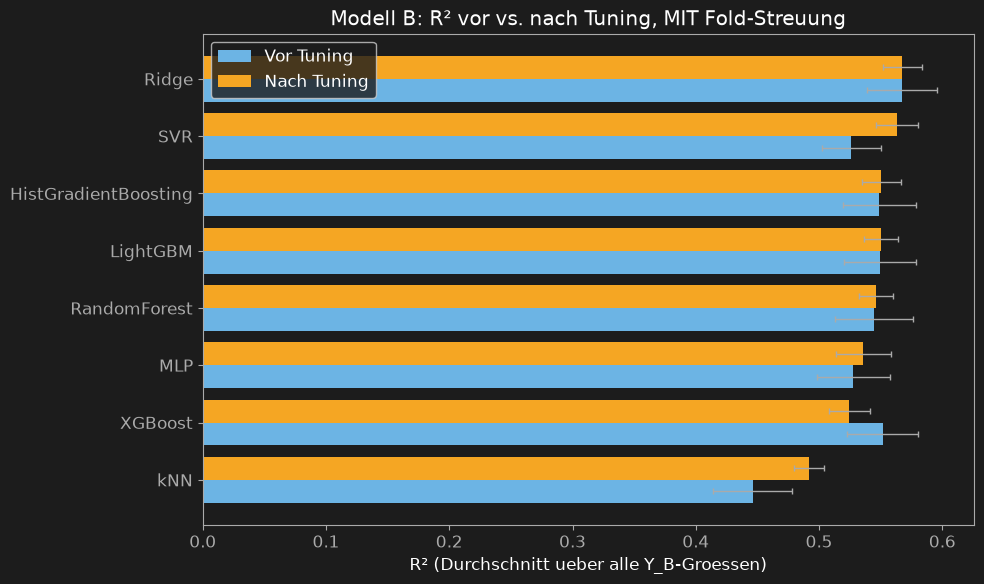

In [10]:
# =============================================================================
# Zelle 07 (korrigiert) – Grafik 1: Vorher-Nachher-Balkendiagramm MIT Fehlerbalken
# =============================================================================
# KORREKTUR: urspruengliche Version zeigte nur Mittelwerte, keine Streuung -
# widerspricht der Lehre aus Notebook 11 (Fold-Ueberlappung muss immer
# mitbetrachtet werden). r2_std_vor fehlt noch in unserer Tabelle - muss
# aus 11_gesamtvergleich_mit_std.csv nachgeladen werden.
# =============================================================================
std_vor_df = pd.read_csv("../reports/tables/11_gesamtvergleich_mit_std.csv")
gesamttabelle_df = gesamttabelle_df.merge(
    std_vor_df[["modell", "r2_std"]].rename(columns={"r2_std": "r2_std_vor"}),
    on="modell", how="left"
)

fig, ax = plt.subplots(figsize=(10, 6))
gesamttabelle_sortiert = gesamttabelle_df.sort_values("r2_nach", ascending=True)
y_pos = np.arange(len(gesamttabelle_sortiert))

ax.barh(y_pos - 0.2, gesamttabelle_sortiert["r2_vor"], height=0.4, color=COLOR_BLUE, label="Vor Tuning",
        xerr=gesamttabelle_sortiert["r2_std_vor"], error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=2, elinewidth=1))
ax.barh(y_pos + 0.2, gesamttabelle_sortiert["r2_nach"], height=0.4, color=COLOR_GOLD, label="Nach Tuning",
        xerr=gesamttabelle_sortiert["r2_std_nach"], error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=2, elinewidth=1))
ax.set_yticks(y_pos)
ax.set_yticklabels(gesamttabelle_sortiert["modell"])
ax.set_xlabel("R² (Durchschnitt ueber alle Y_B-Groessen)")
ax.set_title("Modell B: R² vor vs. nach Tuning, MIT Fold-Streuung")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/07_vorher_nachher_balken_mit_std.png")
plt.show()

## Interpretation: R²-Ergebnisse nach systematischem Tuning

### Was die Zahlen bedeuten

R² zwischen 0.45 und 0.57 bedeutet: das jeweilige Modell erklärt
**45-57% der Streuung** der sechs Prozesseinstellungen (Schneckendrehzahl,
Massetemperatur, Düsenspalt, Vakuumniveau, Innenluftdruck,
Kühlwassertemperatur) im Durchschnitt über alle sechs Größen hinweg -
der Rest bleibt unerklärt (eingebautes Rauschen in der Datengenerierung
plus tatsächlich nicht erfasste Einflussfaktoren).

### Zentrale Erkenntnis aus dem Tuning

Nur 2 von 8 Modellen (kNN, SVR) profitierten nachweisbar vom
systematischen Tuning - beide zeigten vorher ungeprüfte, suboptimale
Hyperparameter (kNN: zu wenige Nachbarn; SVR: zu starke Regularisierung).
Die übrigen 6 Modelle blieben im Rahmen der normalen Fold-Streuung
unverändert, XGBoost verschlechterte sich sogar deutlich (Gap von 0.093
auf 0.211 mehr als verdoppelt - Hinweis auf Tuning-Instabilität bei
diesem Modell für diese Datenmenge).

**Ridge bleibt nach dem vollständigen Tuning der robusteste
Gesamtkandidat:** höchstes R² (0.5675 ± 0.016), mit Abstand kleinster
Gap (0.0062), praktisch keine Fit-/Predict-Zeit. **SVR hat sich zum
einzigen ernstzunehmenden Herausforderer entwickelt** (0.5632 ± 0.017,
Gap 0.0136 nach Tuning deutlich verbessert) - beide Streuungsbereiche
überlappen sich, ein robuster Genauigkeitsunterschied zwischen Ridge und
SVR ist nicht nachweisbar.

### Bedeutung für unseren Anwendungsfall

**Die Genauigkeit (R²≈0.57) ist für ein Assistenzsystem in der
Praxis nutzbar, aber nicht perfekt** - Modell B liefert einem neuen
Mitarbeiter einen **guten, datengetriebenen Startpunkt** für die
Prozesseinstellung bei einem neuen Auftrag, ersetzt aber nicht die
erfahrungsbasierte Feinjustierung durch den Experten während der
Inbetriebnahme (konsistent mit unserem ursprünglichen Konzept: Modell B
als Startpunkt-Vorschlag, nicht als vollautomatische Lösung).

**Die durchgängig kleine Fold-Streuung (Std meist 0.012-0.022) ist ein
gutes Zeichen für die praktische Verlässlichkeit** - das Modell liefert
über verschiedene Trainings-Teilmengen hinweg konsistente Vorhersagen,
kein Hinweis auf Instabilität (mit Ausnahme von XGBoost nach Tuning).

**Ridge als führendes, lineares Modell hat einen zusätzlichen
praktischen Vorteil für die geplante Streamlit-Anwendung:** extrem
schnelle Fit-/Predict-Zeit ermöglicht eine reaktionsschnelle,
interaktive Nutzung ohne spürbare Wartezeit - ein Vorteil, den
komplexere Modelle (insb. SVR mit Predict-Zeit ~0.66s) nicht in
gleichem Maße bieten.

### Wichtige Einschränkung, ehrlich benannt

R²≈0.57 bedeutet auch: **fast die Hälfte der Streuung bleibt
unerklärt.** Wie bereits in der EDA erkannt (Notebook 09), variiert die
Vorhersagbarkeit stark zwischen den sechs Zielgrößen (Düsenspalt sehr
gut erklärbar, Kühlwassertemperatur/Vakuumniveau deutlich schwächer) -
der Gesamtdurchschnitt verdeckt diese Bandbreite. Eine differenzierte
Aussage je Zielgröße bleibt für die praktische Anwendung wichtig, nicht
nur der aggregierte Wert.

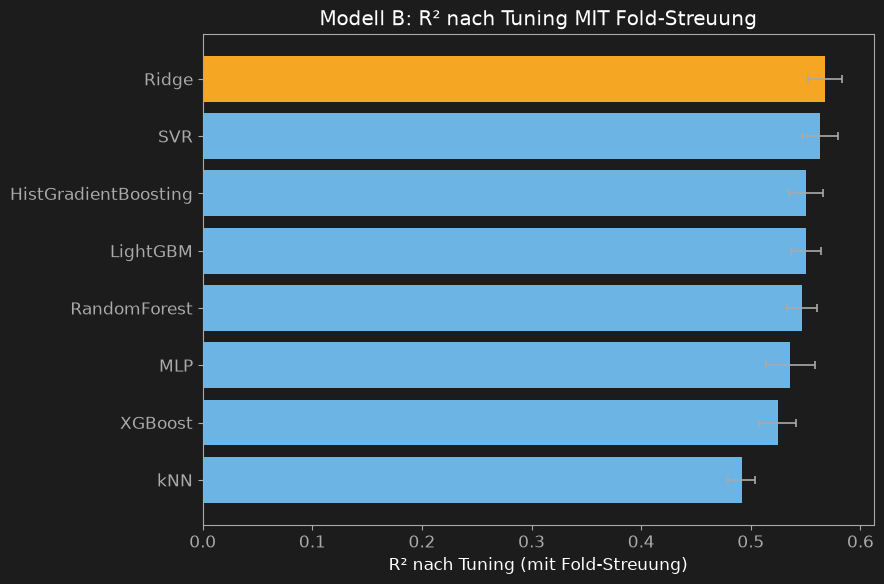

In [11]:
# =============================================================================
# Zelle 08 – Grafik 2: R2 nach Tuning MIT Fehlerbalken (Std) – geprueft
# =============================================================================
# Nutzt bereits vorhandene r2_std_nach-Spalte (aus Zelle 04/06 Tuning-
# Ergebnissen) - Streuung war hier von Anfang an vorgesehen, keine
# nachtraegliche Korrektur noetig wie bei Zelle 07.
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
sortiert = gesamttabelle_df.sort_values("r2_nach", ascending=True)
farben = [COLOR_GOLD if m == sortiert.iloc[-1]["modell"] else COLOR_BLUE for m in sortiert["modell"]]

ax.barh(sortiert["modell"], sortiert["r2_nach"], xerr=sortiert["r2_std_nach"],
        color=farben, error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2, elinewidth=1.2))
ax.set_xlabel("R² nach Tuning (mit Fold-Streuung)")
ax.set_title("Modell B: R² nach Tuning MIT Fold-Streuung")
plt.tight_layout()
save_figure(fig, "../reports/figures/08_r2_getunt_mit_fehlerbalken.png")
plt.show()

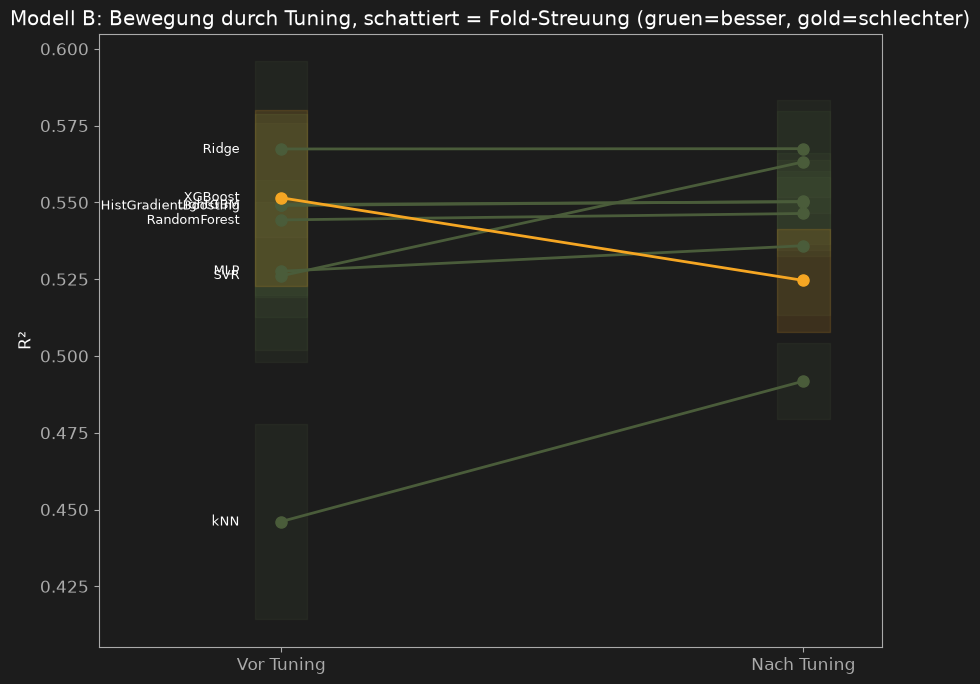

In [12]:
# =============================================================================
# Zelle 09 – Grafik 3: Slope-Chart MIT schattierter Streuung
# =============================================================================
# Zeigt die Bewegung R2 vorher->nachher als Linie, ergaenzt um einen
# schattierten Bereich (Mittelwert +/- Std) an jedem der beiden Punkte -
# macht sichtbar, ob die "Bewegung" ueber die reine Fold-Streuung hinausgeht.
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))

for _, row in gesamttabelle_df.iterrows():
    farbe = COLOR_GREEN if row["r2_nach"] > row["r2_vor"] else (COLOR_GOLD if row["r2_nach"] < row["r2_vor"] else COLOR_TEXT_MUTED)

    # Schattierter Streuungsbereich an beiden Punkten (vorher + nachher)
    ax.fill_between([-0.05, 0.05], row["r2_vor"]-row["r2_std_vor"], row["r2_vor"]+row["r2_std_vor"], color=farbe, alpha=0.15)
    ax.fill_between([0.95, 1.05], row["r2_nach"]-row["r2_std_nach"], row["r2_nach"]+row["r2_std_nach"], color=farbe, alpha=0.15)

    ax.plot([0, 1], [row["r2_vor"], row["r2_nach"]], marker="o", color=farbe, linewidth=2, markersize=8, zorder=3)
    ax.text(-0.08, row["r2_vor"], row["modell"], ha="right", va="center", fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Vor Tuning", "Nach Tuning"])
ax.set_ylabel("R²")
ax.set_title("Modell B: Bewegung durch Tuning, schattiert = Fold-Streuung (gruen=besser, gold=schlechter)")
ax.set_xlim(-0.35, 1.15)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_slope_chart_tuning_mit_streuung.png")
plt.show()

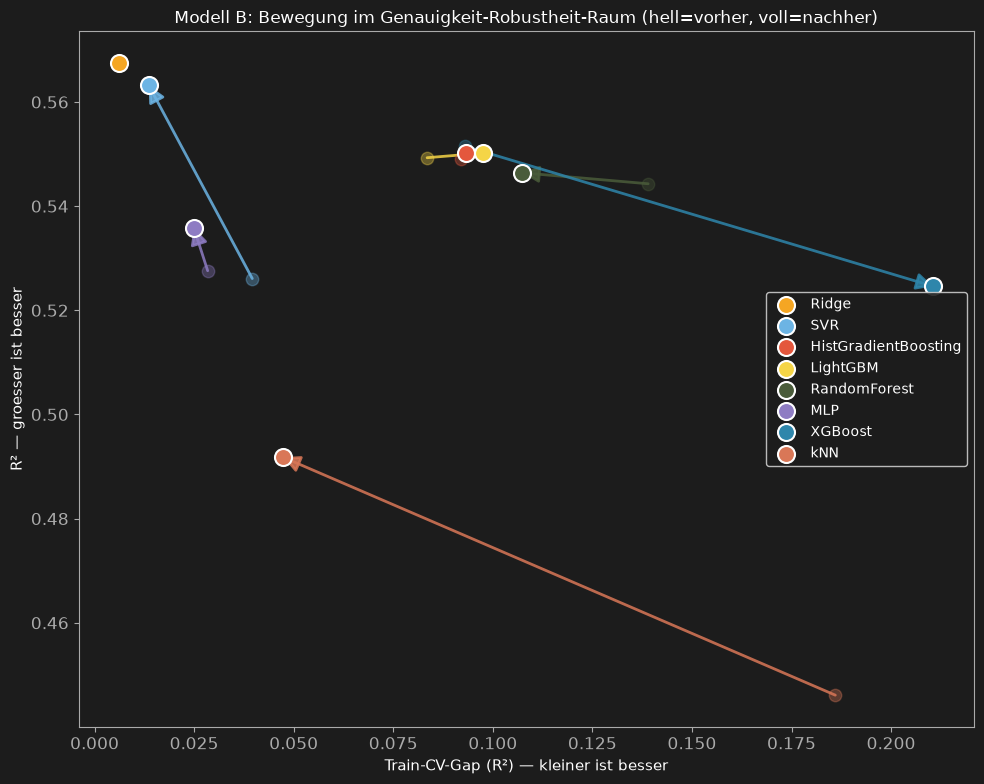

In [23]:
# =============================================================================
# Zelle 10 (final) – Pfeilspitze vergroessert
# =============================================================================
modell_farben_b_v2 = {
    "Ridge": "#F5A623", "SVR": "#6CB4E4", "kNN": "#D97757", "MLP": "#8E7CC3",
    "RandomForest": "#4A5C3A", "HistGradientBoosting": "#E4573D",
    "XGBoost": "#2E86AB", "LightGBM": "#F5D547",
}

fig, ax = plt.subplots(figsize=(10, 8))
for _, row in gesamttabelle_df.iterrows():
    farbe = modell_farben_b_v2.get(row["modell"], COLOR_TEXT_MUTED)
    bewegung = np.hypot(row["gap_nach"]-row["gap_vor"], row["r2_nach"]-row["r2_vor"])

    ax.scatter(row["gap_vor"], row["r2_vor"], color=farbe, s=80, alpha=0.35, marker="o", zorder=2)
    ax.scatter(row["gap_nach"], row["r2_nach"], color=farbe, s=150, alpha=1.0, marker="o",
               edgecolors="white", linewidths=1.5, zorder=3, label=row["modell"])

    if bewegung > 0.005:
        ax.annotate("", xy=(row["gap_nach"], row["r2_nach"]), xytext=(row["gap_vor"], row["r2_vor"]),
                    arrowprops=dict(arrowstyle="-|>", color=farbe, alpha=0.85, lw=2.0,
                                     shrinkA=0, shrinkB=0, mutation_scale=25), zorder=1)

ax.set_xlabel("Train-CV-Gap (R²) — kleiner ist besser", fontsize=11)
ax.set_ylabel("R² — groesser ist besser", fontsize=11)
ax.set_title("Modell B: Bewegung im Genauigkeit-Robustheit-Raum (hell=vorher, voll=nachher)", fontsize=12)
ax.legend(fontsize=10, loc="center right", framealpha=0.9)
plt.tight_layout()
save_figure(fig, "../reports/figures/10_gap_r2_bewegung_mit_legende.png")
plt.show()

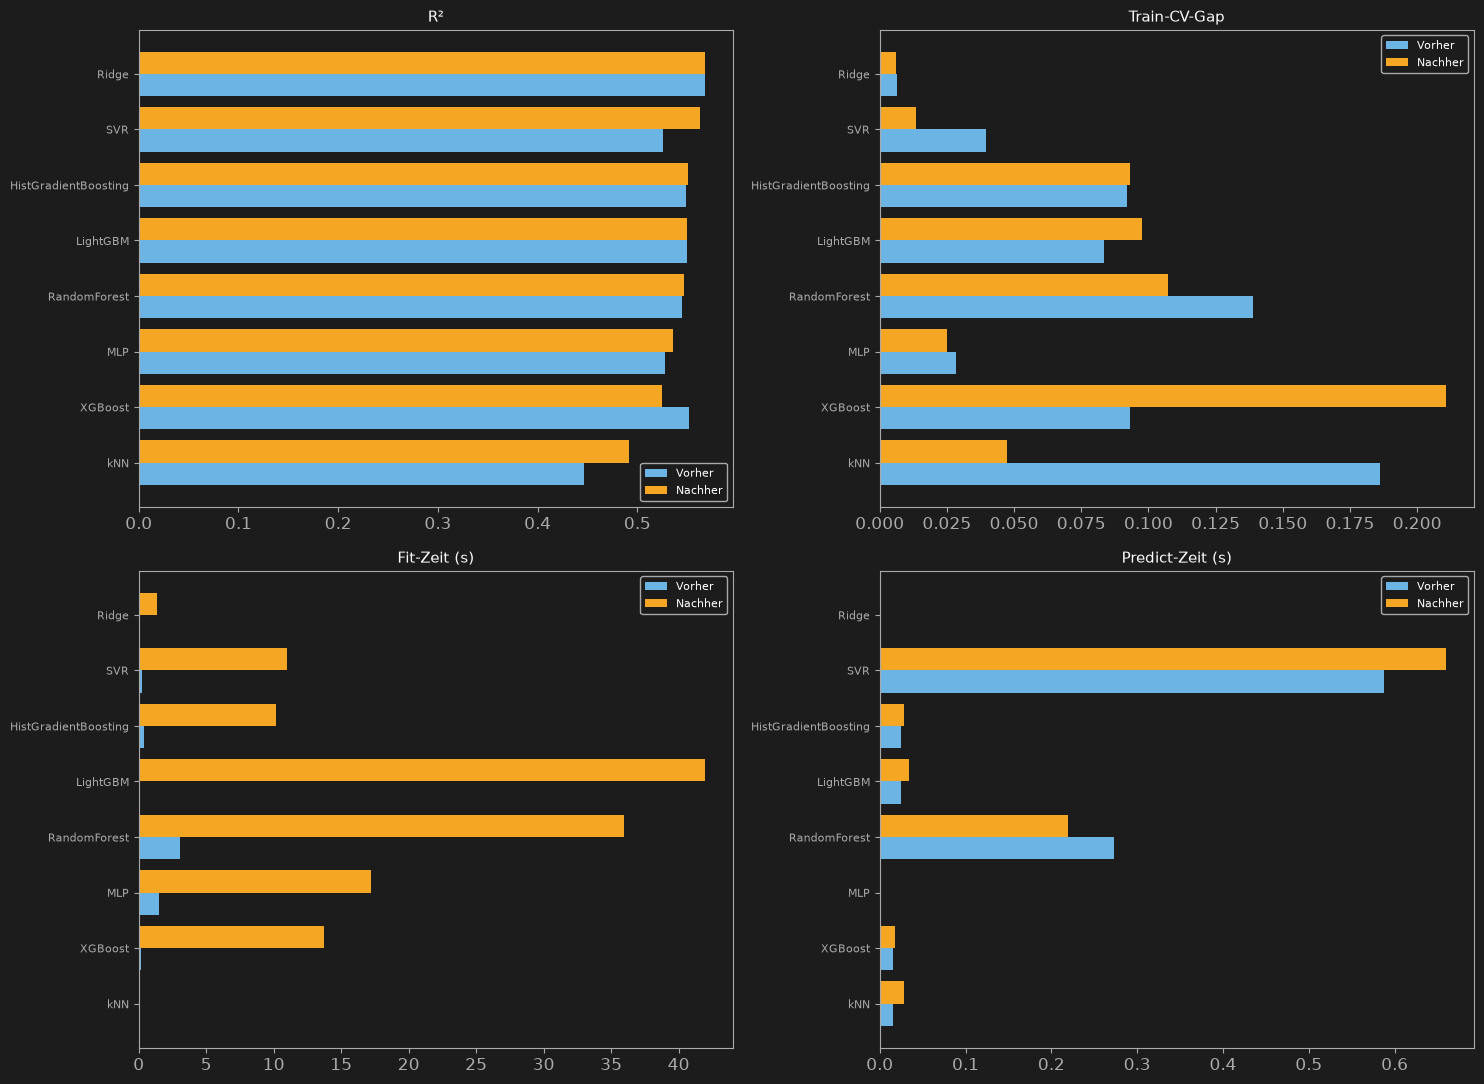

In [24]:
# =============================================================================
# Zelle 11 – Grafik 5: Vierfeld-Ansicht (R2, Gap, Fit-Zeit, Predict-Zeit)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sortiert = gesamttabelle_df.sort_values("r2_nach", ascending=True)

metriken_panels = [
    ("r2_vor", "r2_nach", "R²", axes[0,0]),
    ("gap_vor", "gap_nach", "Train-CV-Gap", axes[0,1]),
    ("fit_zeit_vor", "fit_zeit_nach", "Fit-Zeit (s)", axes[1,0]),
    ("predict_zeit_vor", "predict_zeit_nach", "Predict-Zeit (s)", axes[1,1]),
]

for vor_col, nach_col, titel, ax in metriken_panels:
    y_pos = np.arange(len(sortiert))
    ax.barh(y_pos - 0.2, sortiert[vor_col], height=0.4, color=COLOR_BLUE, label="Vorher")
    ax.barh(y_pos + 0.2, sortiert[nach_col], height=0.4, color=COLOR_GOLD, label="Nachher")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sortiert["modell"], fontsize=8)
    ax.set_title(titel, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, "../reports/figures/11_vierfeld_uebersicht.png")
plt.show()

## Finale Champion-Entscheidung: Ridge

### Vollständiger Vergleich Ridge vs. SVR (die zwei Spitzenkandidaten)

| Kriterium | Ridge | SVR | Vorteil |
|---|---|---|---|
| R² (nach Tuning) | 0.5675 ± 0.0157 | 0.5632 ± 0.0167 | Ridge (minimal, Streuung überlappt) |
| Train-CV-Gap | 0.0062 | 0.0136 | **Ridge** (mehr als doppelt so klein) |
| Fit-Zeit | 1.34s | 11.00s | **Ridge** (~8× schneller) |
| Predict-Zeit | ~0.0000s | 0.6595s | **Ridge** (für Echtzeitanwendung relevant) |
| Erklärbarkeit | LinearExplainer (exakt, schnell) | KernelExplainer (approximativ, langsam) | **Ridge** |

**Ridge gewinnt in jeder gemessenen Dimension entweder eigenständig oder
liegt gleichauf** - kein Kriterium unserer Analyse spricht für SVR.
Die theoretische Flexibilität von SVR (nichtlineare Zusammenhänge über
RBF-Kernel abbildbar) bringt hier keinen praktischen Vorteil, da die
EDA (Notebook 09) bereits zeigte, dass die meisten X_B→Y_B-Beziehungen
überwiegend linear/monoton sind - das empirische Ergebnis bestätigt
diese Erkenntnis unabhängig.

### Wichtige Einschränkung für zukünftige Daten

**Ridge ist ein rein lineares Modell.** Die Champion-Entscheidung gilt
für die aktuelle, synthetische Datenbasis, die überwiegend lineare
Zusammenhänge zeigt. **Bei neuen, realen Daten - insbesondere falls sich
nichtlineare Effekte zeigen, die in unserer synthetischen Konstruktion
nicht abgebildet sind - sollte diese Entscheidung erneut überprüft
werden.** Ein rein lineares Modell kann strukturell an eine Grenze
stoßen, die ein flexibleres Modell (SVR, Boosting-Verfahren) besser
bewältigen könnte, falls die zugrunde liegende Prozessphysik komplexer
ist als in dieser Studie angenommen.

In [25]:
# =============================================================================
# Zelle 13 – R2 je einzelner Y_B-Groesse fuer Ridge (nach Tuning)
# =============================================================================
# Prueft, ob der Gesamtdurchschnitt (R2=0.5675) eine grosse Bandbreite
# zwischen den 6 Zielgroessen verdeckt - analog zur Erkenntnis aus
# Notebook 11 (unkalibrierte Version).
# =============================================================================
ridge_konfig = SUCHRAEUME_B["Ridge"]
ridge_r2_je_y = {}

for y_col in Y_B_MERKMALE:
    fold_scores = []
    for tr_idx, val_idx in fold_splits_idx:
        prep = baue_preprocessing_pipeline_b("original")
        X_tr = prep.fit_transform(df_b.loc[tr_idx])
        X_val = prep.transform(df_b.loc[val_idx])
        y_tr_alle = df_b.loc[tr_idx, Y_B_MERKMALE]
        y_val_single = df_b.loc[val_idx, y_col]

        innere_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
        grid = GridSearchCV(clone(ridge_konfig["modell"]), ridge_konfig["params"], scoring="r2", cv=innere_cv, n_jobs=-1)
        grid.fit(X_tr, y_tr_alle)
        y_pred = grid.predict(X_val)
        y_pred_single = pd.DataFrame(y_pred, columns=Y_B_MERKMALE)[y_col].values
        fold_scores.append(r2_score(y_val_single, y_pred_single))

    ridge_r2_je_y[y_col] = {"r2_mean": round(np.mean(fold_scores), 3), "r2_std": round(np.std(fold_scores), 3)}

ridge_je_y_df = pd.DataFrame(ridge_r2_je_y).T.sort_values("r2_mean", ascending=False)
print(ridge_je_y_df.to_string())

pfad_ridge_je_y = "../reports/tables/12_ridge_r2_je_y_b_groesse.csv"
ridge_je_y_df.to_csv(pfad_ridge_je_y)
print(f"\nGespeichert in: {pfad_ridge_je_y}")

                       r2_mean  r2_std
duesenspalt              0.950   0.006
schneckendrehzahl        0.831   0.019
innenluftdruck           0.517   0.036
massetemperatur          0.475   0.029
vakuumniveau             0.367   0.035
kuehlwassertemperatur    0.266   0.047

Gespeichert in: ../reports/tables/12_ridge_r2_je_y_b_groesse.csv


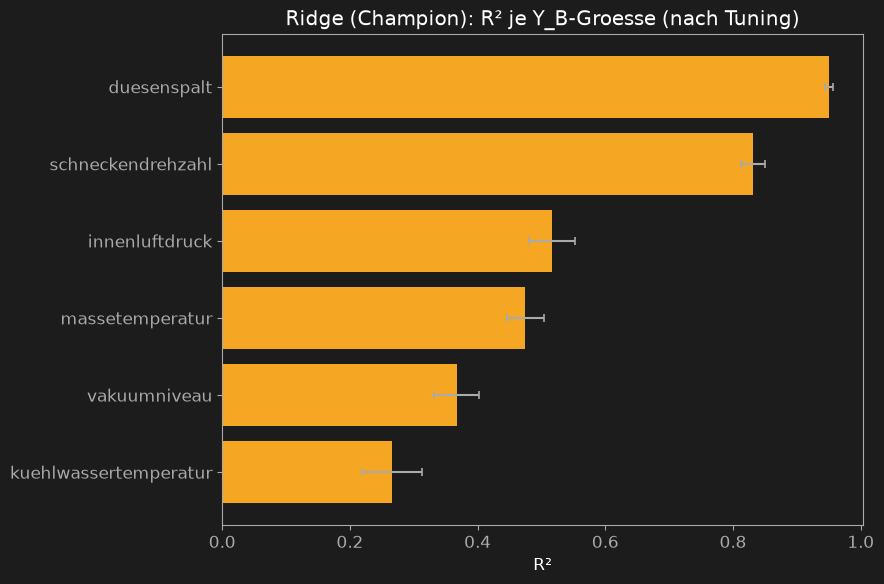

In [26]:
# =============================================================================
# Zelle 14 – Grafik: Ridge R2 je Y_B-Groesse (mit Fold-Streuung)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
sortiert = ridge_je_y_df.sort_values("r2_mean", ascending=True)
ax.barh(sortiert.index, sortiert["r2_mean"], xerr=sortiert["r2_std"],
        color=COLOR_GOLD, error_kw=dict(ecolor=COLOR_TEXT_MUTED, capsize=3, capthick=1.2))
ax.set_xlabel("R²")
ax.set_title("Ridge (Champion): R² je Y_B-Groesse (nach Tuning)")
plt.tight_layout()
save_figure(fig, "../reports/figures/14_ridge_r2_je_yb.png")
plt.show()

In [ ]:
# =============================================================================
# Zelle 15 – R2 je einzelner Y_B-Groesse fuer SVR (nach Tuning, zum Vergleich)
# =============================================================================
svr_konfig = SUCHRAEUME_B["SVR"]
svr_r2_je_y = {}

for y_col in Y_B_MERKMALE:
    fold_scores = []
    for tr_idx, val_idx in fold_splits_idx:
        prep = baue_preprocessing_pipeline_b("original")
        X_tr = prep.fit_transform(df_b.loc[tr_idx])
        X_val = prep.transform(df_b.loc[val_idx])
        y_tr_single = df_b.loc[tr_idx, y_col]
        y_val_single = df_b.loc[val_idx, y_col]

        innere_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
        grid = GridSearchCV(clone(svr_konfig["modell"]), svr_konfig["params"], scoring="r2", cv=innere_cv, n_jobs=-1)
        grid.fit(X_tr, y_tr_single)
        y_pred_single = grid.predict(X_val)
        fold_scores.append(r2_score(y_val_single, y_pred_single))

    svr_r2_je_y[y_col] = {"r2_mean": round(np.mean(fold_scores), 3), "r2_std": round(np.std(fold_scores), 3)}

svr_je_y_df = pd.DataFrame(svr_r2_je_y).T.sort_values("r2_mean", ascending=False)
print(svr_je_y_df.to_string())

pfad_svr_je_y = "../reports/tables/12_svr_r2_je_y_b_groesse.csv"
svr_je_y_df.to_csv(pfad_svr_je_y)
print(f"\nGespeichert in: {pfad_svr_je_y}")